In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

path = "data/tennis_atp/atp_matches_qual_chall_2020.csv"

df = pd.read_csv(path)

df["tourney_date"] = pd.to_datetime(df["tourney_date"], format="%Y%m%d")

print(f"Loaded {len(df)} matches.")
df.head()

Loaded 3288 matches.


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2020-0083,Eckental CH,Hard,32,C,2020-11-02,243,122351,5.0,NaN,...,21.0,14.0,8.0,7.0,3.0,7.0,329.0,129.0,1314.0,4.0
1,2020-0083,Eckental CH,Hard,32,C,2020-11-02,244,127760,4.0,NaN,...,32.0,23.0,11.0,9.0,2.0,4.0,315.0,138.0,507.0,63.0
2,2020-0083,Eckental CH,Hard,32,C,2020-11-02,245,207213,7.0,NaN,...,68.0,45.0,25.0,16.0,7.0,13.0,386.0,101.0,NaN,NaN
3,2020-0083,Eckental CH,Hard,32,C,2020-11-02,247,202359,NaN,Alt,...,23.0,17.0,15.0,10.0,3.0,7.0,1495.0,2.0,355.0,114.0
4,2020-0083,Eckental CH,Hard,32,C,2020-11-02,248,104897,2.0,NaN,...,38.0,34.0,17.0,11.0,6.0,7.0,278.0,180.0,403.0,94.0


Putting all the csv data into a dataframe

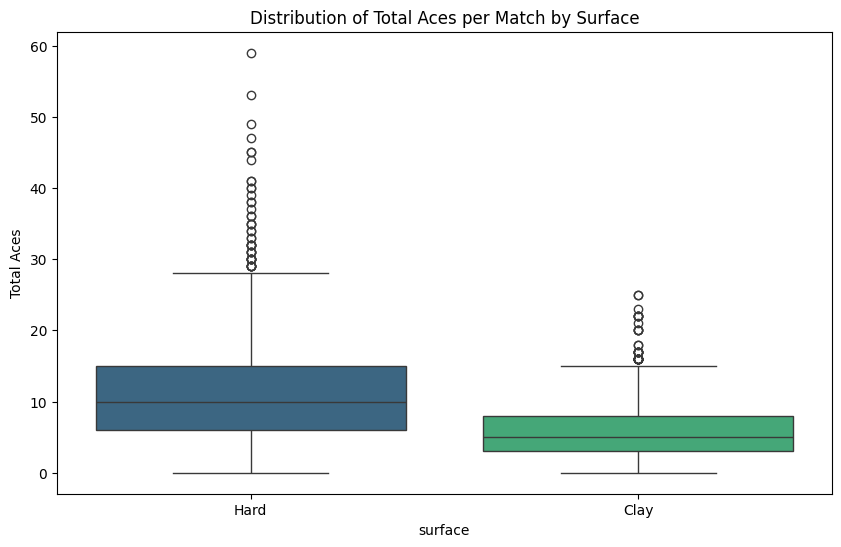

In [4]:
df["total_aces"] = df["w_ace"] + df["l_ace"]

# Drop rows where 'surface' or 'total_aces' are NaN before plotting
df_plot = df.dropna(subset=["surface", "total_aces"])

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df_plot, x="surface", y="total_aces", hue="surface", palette="viridis"
)
plt.title("Distribution of Total Aces per Match by Surface")
plt.ylabel("Total Aces")
if ax.get_legend() is not None:
    ax.get_legend().remove()
plt.show()

Non-null w_1stWon values: 3257
Non-null w_1stIn values: 3257
Number of zero w_1stIn values: 0


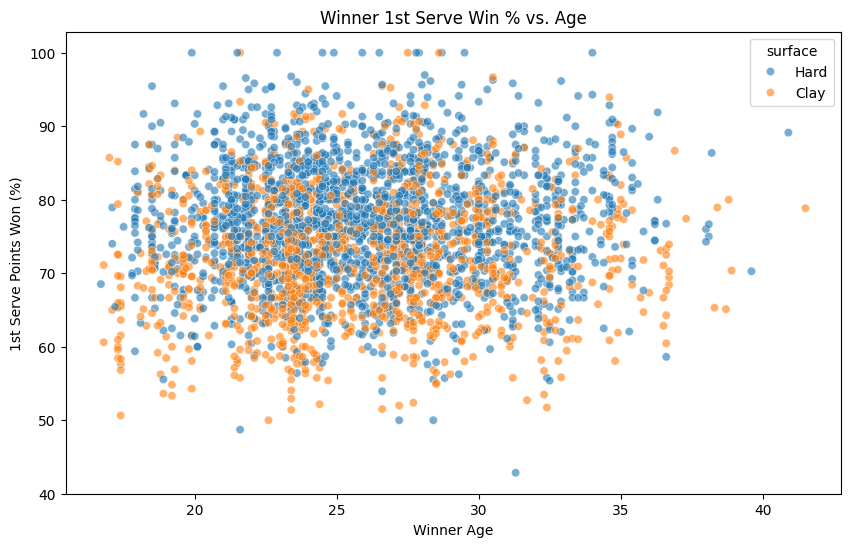

In [5]:
print(f"Non-null w_1stWon values: {df['w_1stWon'].count()}")
print(f"Non-null w_1stIn values: {df['w_1stIn'].count()}")
print(f"Number of zero w_1stIn values: {(df['w_1stIn'] == 0).sum()}")

df["w_1st_win_pct"] = (df["w_1stWon"] / df["w_1stIn"].replace(0, pd.NA)) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="winner_age", y="w_1st_win_pct", hue="surface", alpha=0.6)
plt.title("Winner 1st Serve Win % vs. Age")
plt.xlabel("Winner Age")
plt.ylabel("1st Serve Points Won (%)")
plt.show()